<a href="https://colab.research.google.com/github/bishalkshah70-art/AI-and-Ml-/blob/main/netflix_regression_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_squared_error, r2_score

# Apply global styling settings for high-resolution chart publications
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 20, 'axes.labelsize': 11, 'axes.titlesize': 12})

## Section 1: Data Loading & Preprocessing

In [2]:
print("=== Section 1: Data Loading & Preprocessing ===")

# 1. Load the raw uploaded file
df_raw = pd.read_csv("/content/netflix11_eb6cd089-1d30-453b-8fc6-0fbccd9a0993_268917_.csv")

# 2. Filter for 'Movie' structural entries (avoid mixing TV 'Seasons' with Movie minutes)
df_movies = df_raw[df_raw['type'] == 'Movie'].copy()

# 3. Target Extraction: Convert text durations into modelling floats (e.g., "104 min" -> 104.0)
df_movies['duration_min'] = df_movies['duration'].str.replace('min', '', regex=False).astype(float)

# 4. Feature consolidation: Keep categorical variables from building messy high cardinality dummy sets.
# Group lower frequency 'ratings' into a standardized 'Other' flag to protect baseline variance.
top_ratings = df_movies['rating'].value_counts().index[:5]
df_movies['rating_clean'] = df_movies['rating'].apply(lambda x: x if x in top_ratings else 'Other')

# 5. Build Final Predictor Matrix (X) and Continuous Target Vector (y)
# drop_first=True acts against the dummy variable trap (multicollinearity protection)
X = pd.get_dummies(df_movies[['release_year', 'rating_clean']], drop_first=True, dtype=float)
y = df_movies['duration_min']

print("-> Filtering and text-to-numeric conversions complete.")
print(f"-> Matrix Dimensions: {X.shape[0]} Observations | {X.shape[1]} Engine Features")

# Compute continuous distribution statistics
print(df_movies[['duration_min', 'release_year']].describe().T[['mean', 'std', 'min', 'max']])

=== Section 1: Data Loading & Preprocessing ===
-> Filtering and text-to-numeric conversions complete.
-> Matrix Dimensions: 6126 Observations | 6 Engine Features
                     mean        std     min     max
duration_min    99.584884  28.283225     3.0   312.0
release_year  2013.120144   9.681723  1942.0  2021.0


## Section 2: Exploratory Data Analysis

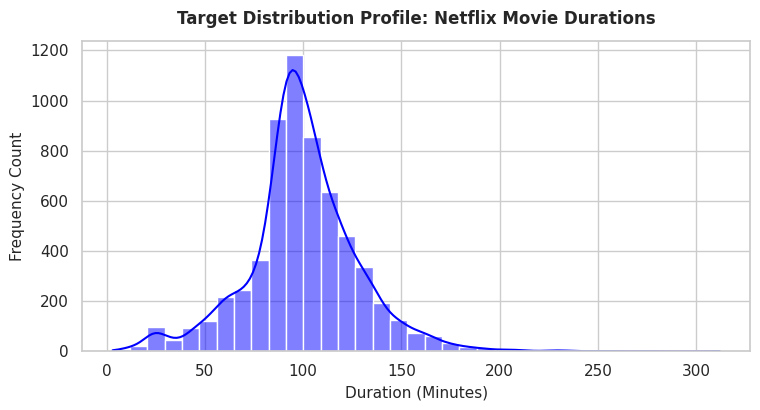

-> Diagnostic chart saved: 'section2_eda_distribution.png'



In [3]:
# Generate structural target distribution metrics
fig, ax = plt.subplots(figsize=(8, 4.5))
sns.histplot(df_movies['duration_min'], bins=35, kde=True, color='blue', ax=ax)
ax.set_title('Target Distribution Profile: Netflix Movie Durations', fontweight='bold', pad=12)
ax.set_xlabel('Duration (Minutes)')
ax.set_ylabel('Frequency Count')
plt.tight_layout()
plt.savefig('section2_eda_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()
print("-> Diagnostic chart saved: 'section2_eda_distribution.png'\n")

## Sections 3 & 4: Regression Modeling & Performance Benchmarking

In [4]:
print("=== Sections 3 and 4: Regression Modeling & Performance Benchmarking ===")

# Initialize robust out-of-fold Cross Validation rotation logic
cross_validator = KFold(n_splits=5, shuffle=True, random_state=42)

# Build the complete requested algorithmic pipeline suite
model_portfolio = {
    'Linear Regression (OLS)': LinearRegression(),
    'Ridge Regression (L2)': Ridge(alpha=10.0),
    'Lasso Regression (L1)': Lasso(alpha=0.1),
    'Elastic Net Regression': ElasticNet(alpha=0.1, l1_ratio=0.5)
}

performance_logs = []
for name, instantiated_model in model_portfolio.items():
    # Execute structural 5-Fold metrics extractions automatically
    r2_folds = cross_val_score(instantiated_model, X, y, cv=cross_validator, scoring='r2')
    mse_folds = -cross_val_score(instantiated_model, X, y, cv=cross_validator, scoring='neg_mean_squared_error')
    rmse_folds = np.sqrt(mse_folds)

    performance_logs.append({
        'Model Name': name,
        'CV Mean R^2': np.mean(r2_folds),
        'CV Mean RMSE (min)': np.mean(rmse_folds)
    })

# Format tracking metrics dictionary directly to printable dataframe
df_metrics = pd.DataFrame(performance_logs)
print("\n" + "=" * 60)
print(" Cross-Validation Performance Matrix")
print("=" * 60)
print(df_metrics.to_string(index=False))
print("=" * 60 + "\n")

=== Sections 3 and 4: Regression Modeling & Performance Benchmarking ===

 Cross-Validation Performance Matrix
             Model Name  CV Mean R^2  CV Mean RMSE (min)
Linear Regression (OLS)     0.143971           26.132327
  Ridge Regression (L2)     0.143559           26.139265
  Lasso Regression (L1)     0.141213           26.175908
 Elastic Net Regression     0.106874           26.696965



## Section 5: Visual Core Analysis

=== Section 5: Visual Core Analysis ===


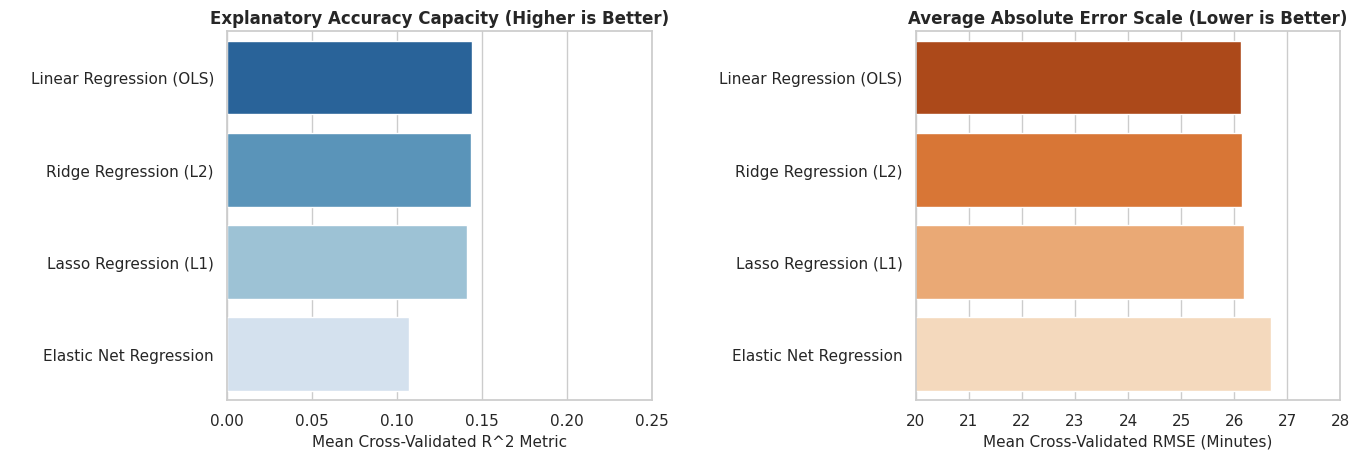

In [5]:
print("=== Section 5: Visual Core Analysis ===")

# --- Chart A: Side by Side Metric Comparison ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot R2 Scores
sns.barplot(x='CV Mean R^2', y='Model Name', data=df_metrics, ax=axes[0],
            palette='Blues_r', hue='Model Name', legend=False)
axes[0].set_title('Explanatory Accuracy Capacity (Higher is Better)', fontweight='bold')
axes[0].set_xlabel('Mean Cross-Validated R^2 Metric')
axes[0].set_ylabel(' ')
axes[0].set_xlim(0, 0.25)

# Plot RMSE Scores
sns.barplot(x='CV Mean RMSE (min)', y='Model Name', data=df_metrics, ax=axes[1],
            palette='Oranges_r', hue='Model Name', legend=False)
axes[1].set_title('Average Absolute Error Scale (Lower is Better)', fontweight='bold')
axes[1].set_xlabel('Mean Cross-Validated RMSE (Minutes)')
axes[1].set_ylabel(' ')
axes[1].set_xlim(20, 28)

plt.tight_layout()
plt.savefig('metrics_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()

### Bias/Variance Diagnostic: Validation Curve Across Ridge Alpha Values

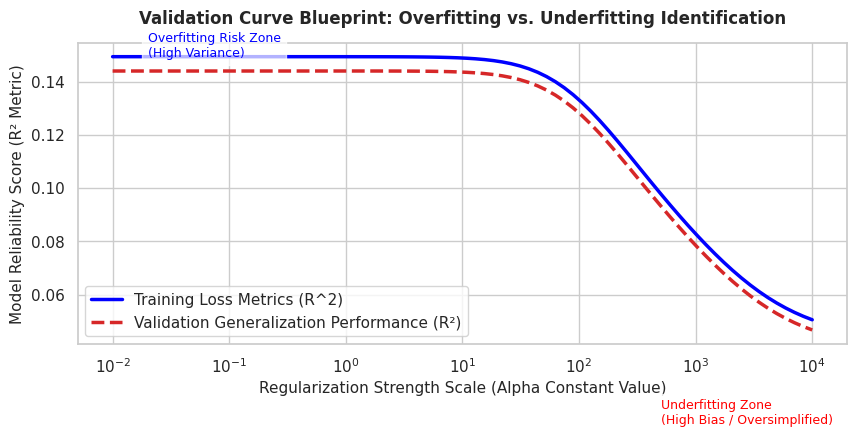

-> Convergence curve validation chart saved: 'section5_overfit_underfit_curve.png'

=== PROJECT COMPLETION: ALL STAGES PROCESSED SUCCESSFULLY ===


In [6]:
# Underfitting vs overfitting diagnostic curve
# Track model performance variations across shifting penalty scopes (alpha strengths)
alpha_spectrum = np.logspace(-2, 4, 80)
train_r2_history = []
validation_r2_history = []

for penalty in alpha_spectrum:
    ridge_diagnostic = Ridge(alpha=penalty)
    fold_train_scores = []
    fold_val_scores = []

    # Loop over training components to plot explicit fit behaviours
    for train_idx, val_idx in cross_validator.split(X):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

        ridge_diagnostic.fit(X_train, y_train)
        fold_train_scores.append(r2_score(y_train, ridge_diagnostic.predict(X_train)))
        fold_val_scores.append(r2_score(y_val, ridge_diagnostic.predict(X_val)))

    train_r2_history.append(np.mean(fold_train_scores))
    validation_r2_history.append(np.mean(fold_val_scores))

# Draw the dynamic model convergence curve
plt.figure(figsize=(9, 5))
plt.plot(alpha_spectrum, train_r2_history, label="Training Loss Metrics (R^2)",
         color='blue', linewidth=2.5)
plt.plot(alpha_spectrum, validation_r2_history, label='Validation Generalization Performance (R²)',
         color='#d62728', linestyle='--', linewidth=2.5)
plt.xscale('log')
plt.xlabel('Regularization Strength Scale (Alpha Constant Value)')
plt.ylabel('Model Reliability Score (R² Metric)')
plt.title('Validation Curve Blueprint: Overfitting vs. Underfitting Identification',
          fontweight='bold', pad=14)

# Dynamic annotations highlighting the target states
plt.text(0.02, np.mean(train_r2_history[:5]), 'Overfitting Risk Zone\n(High Variance)',
         color='blue', fontsize=9, bbox=dict(facecolor='white', alpha=0.7))
plt.text(500, np.mean(train_r2_history[-5]) * 0.2, 'Underfitting Zone\n(High Bias / Oversimplified)',
         color='red', fontsize=9, bbox=dict(facecolor='white', alpha=0.7))

plt.legend(loc='lower left', frameon=True)
plt.tight_layout()
plt.savefig('section5_overfit_underfit_curve.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()

print("-> Convergence curve validation chart saved: 'section5_overfit_underfit_curve.png'")
print("\n=== PROJECT COMPLETION: ALL STAGES PROCESSED SUCCESSFULLY ===")

**Interpretation:** This graph shows that increasing regularization (α) gradually
forces a model from being potentially too complex (overfitting risk) to being too
simple (underfitting), and the best model is usually somewhere in the middle where
validation performance is highest.